In [1]:
import sqlite3

In [2]:
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [7]:
cursor.execute("""
CREATE TABLE marvel_sales (
    Customer_ID INTEGER,
    First_Name TEXT,
    Last_Name TEXT,
    Product TEXT,
    Quantity INTEGER,
    Price REAL
)
""")

cursor.execute("INSERT INTO marvel_sales VALUES (1,'Tony','Stark','Laptop', 3, 35000)")
cursor.execute("INSERT INTO marvel_sales VALUES (2,'Natasha','Romanoff','Mouse', 13, 1500)")
cursor.execute("INSERT INTO marvel_sales VALUES (3,'Steve','Rogers','Speakers', 8, 4000)")
cursor.execute("INSERT INTO marvel_sales VALUES (4,'Peter','Parker','Moniter', 5, 10000)")
cursor.execute("INSERT INTO marvel_sales VALUES (5,'Bruce','Banner','Keabord', 10, 3000)")
cursor.execute("INSERT INTO marvel_sales VALUES (6,'Cassie','Lang','Headphones', 6, 15000)")
cursor.execute("INSERT INTO marvel_sales VALUES (7,'Scott','Lang','CPU', 2, 40000)")
cursor.execute("INSERT INTO marvel_sales VALUES (8,'Wanda','Maximoff','Camera', 4, 25000)")

conn.commit()

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
query = "SELECT * FROM marvel_sales;"

In [29]:
df = pd.read_sql_query(query,conn)

In [30]:
df

,Customer_ID,First_Name,Last_Name,Product,Quantity,Price
0,1,Tony,Stark,Laptop,3,35000.0
1,2,Natasha,Romanoff,Mouse,13,1500.0
2,3,Steve,Rogers,Speakers,8,4000.0
3,4,Peter,Parker,Moniter,5,10000.0
4,5,Bruce,Banner,Keabord,10,3000.0
5,6,Cassie,Lang,Headphones,6,15000.0
6,7,Scott,Lang,CPU,2,40000.0
7,8,Wanda,Maximoff,Camera,4,25000.0


In [33]:
query = "SELECT Product, SUM(Quantity) AS total_qty, SUM(Quantity * Price) AS revenue FROM marvel_sales GROUP BY Product;"

In [34]:
df = pd.read_sql_query(query,conn)

In [35]:
df

,Product,total_qty,revenue
0,CPU,2,80000.0
1,Camera,4,100000.0
2,Headphones,6,90000.0
3,Keabord,10,30000.0
4,Laptop,3,105000.0
5,Moniter,5,50000.0
6,Mouse,13,19500.0
7,Speakers,8,32000.0


Text(0.5, 1.0, 'Revenue by Product')

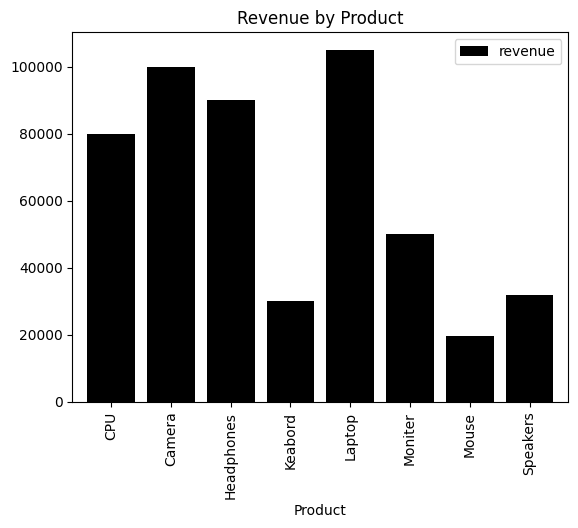

In [58]:
df.plot(kind='bar', x='Product', y='revenue', color='black', width=0.8)
plt.title("Revenue by Product")

In [59]:
plt.savefig("sales_chart.png")

<Figure size 640x480 with 0 Axes>